SVM Classifier for TAU 2019 Acoustic Scenes

- Loading the same grouped train/val/test splits
- Log-mel pooled feature extraction **with caching** to logmel_stats_all.npz
- Hyperparameter search over SVM settings
- Saving CV results to svm_cv_results.csv
- Training a final model and saving it to svm_model.joblib
- Evaluation on the test set + confusion matrix and permutation-based feature importance.

In [7]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
import joblib

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.inspection import permutation_importance
from sklearn.model_selection import StratifiedKFold

sns.set(style='whitegrid')

SR = 22050
RANDOM_STATE = 42

def read_meta(path: str = 'meta.csv') -> pd.DataFrame:
    if not os.path.exists(path):
        raise FileNotFoundError('meta.csv not found')
    meta = pd.read_csv(path, sep='\t', quotechar='"')
    required = ['filename', 'scene_label', 'identifier']
    for c in required:
        if c not in meta:
            raise ValueError(f'Missing {c} in meta')
    meta['filepath'] = meta['filename'].apply(lambda f: os.path.join('.', f))
    return meta

def logmel_stats_from_path(
    path: str,
    sr: int = SR,
    n_mels: int = 128,
    hop_length: int = 1024,
    fmin: int = 50,
    fmax=None,
    use_zscore: bool = True,
    percentiles=(10, 90),
):
    y, sr = librosa.load(path, sr=sr, mono=True)
    S = librosa.feature.melspectrogram(
        y=y, sr=sr, n_mels=n_mels,
        hop_length=hop_length, fmin=fmin, fmax=fmax, power=2.0,
    )
    L = librosa.power_to_db(S, ref=np.max).astype(np.float32)
    if use_zscore:
        mu = float(L.mean())
        sd = float(L.std() + 1e-8)
        L = (L - mu) / sd
    mu = L.mean(axis=1)
    sd = L.std(axis=1)
    p_lo, p_hi = np.percentile(L, percentiles[0], axis=1), np.percentile(L, percentiles[1], axis=1)
    return np.concatenate([mu, sd, p_lo, p_hi]).astype(np.float32)

def build_logmel_stats_matrix(paths, **kwargs) -> np.ndarray:
    feats = [logmel_stats_from_path(p, **kwargs) for p in paths]
    return np.vstack(feats)

def make_svm():
    return Pipeline([
        ('scaler', StandardScaler()),
        ('svm', SVC(kernel='rbf', class_weight='balanced')),
    ])


In [8]:
# load splits
splits = np.load('splits_tau2019_grouped.npz')
tr_idx, va_idx, te_idx = splits['tr_idx'], splits['va_idx'], splits['te_idx']
meta = read_meta('meta.csv')
filepaths = meta['filepath'].tolist()
labels = meta['scene_label'].to_numpy()

le = LabelEncoder()
y_all = le.fit_transform(labels)
class_names = le.classes_
class_names


array(['airport', 'bus', 'metro', 'metro_station', 'park',
       'public_square', 'shopping_mall', 'street_pedestrian',
       'street_traffic', 'tram'], dtype=object)

In [10]:
# build features
if os.path.exists('logmel_stats_all.npz'):
    data = np.load('logmel_stats_all.npz')
    X_all = data['X_all']
    print('Loaded cached log-mel features from logmel_stats_all.npz')
else:
    X_all = build_logmel_stats_matrix(
        filepaths,
        sr=SR,
        n_mels=128,
        hop_length=1024,
        fmin=50,
        fmax=None,
        use_zscore=True,
        percentiles=(10, 90),
    )
    np.savez('logmel_stats_all.npz', X_all=X_all)
    print('Computed and cached log-mel features to logmel_stats_all.npz')
print('Feature matrix shape:', X_all.shape)

X_tr, X_va, X_te = X_all[tr_idx], X_all[va_idx], X_all[te_idx]
y_tr, y_va, y_te = y_all[tr_idx], y_all[va_idx], y_all[te_idx]
X_tr.shape, X_va.shape, X_te.shape


Loaded cached log-mel features from logmel_stats_all.npz
Feature matrix shape: (14400, 512)


((9309, 512), (2347, 512), (2744, 512))

In [13]:
# hyperparameter
param_space = [
    {'svm__C': c, 'svm__gamma': g}
    for c in [0.1, 1.0, 10.0]
    for g in ['scale', 1e-3, 1e-4]
]

best_params = None
best_val_acc = -np.inf
cv_rows = []

for params in param_space:
    clf = make_svm()
    clf.set_params(**params)
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    cv_accs = []
    for tr_fold, va_fold in skf.split(X_tr, y_tr):
        clf.fit(X_tr[tr_fold], y_tr[tr_fold])
        y_pred_fold = clf.predict(X_tr[va_fold])
        cv_accs.append(accuracy_score(y_tr[va_fold], y_pred_fold))
    mean_cv = float(np.mean(cv_accs))
    std_cv = float(np.std(cv_accs))
    print('Params:', params, 'CV acc:', mean_cv)
    cv_rows.append({'C': params['svm__C'], 'gamma': params['svm__gamma'],
                    'mean_acc': mean_cv, 'std_acc': std_cv})
    if mean_cv > best_val_acc:
        best_val_acc = mean_cv
        best_params = params

cv_df = pd.DataFrame(cv_rows)
cv_df.to_csv('svm_cv_results.csv', index=False)
print('Saved CV results to svm_cv_results.csv')

print('Best params:', best_params)
print('Best CV accuracy:', best_val_acc)


Params: {'svm__C': 0.1, 'svm__gamma': 'scale'} CV acc: 0.6139216930019837
Params: {'svm__C': 0.1, 'svm__gamma': 0.001} CV acc: 0.5864206266799262
Params: {'svm__C': 0.1, 'svm__gamma': 0.0001} CV acc: 0.42227963783720446
Params: {'svm__C': 1.0, 'svm__gamma': 'scale'} CV acc: 0.8139434523208304
Params: {'svm__C': 1.0, 'svm__gamma': 0.001} CV acc: 0.7569018885588117
Params: {'svm__C': 1.0, 'svm__gamma': 0.0001} CV acc: 0.5919004542907127
Params: {'svm__C': 10.0, 'svm__gamma': 'scale'} CV acc: 0.8954773515503659
Params: {'svm__C': 10.0, 'svm__gamma': 0.001} CV acc: 0.8695887835040121
Params: {'svm__C': 10.0, 'svm__gamma': 0.0001} CV acc: 0.7183372186511416
Saved CV results to svm_cv_results.csv
Best params: {'svm__C': 10.0, 'svm__gamma': 'scale'}
Best CV accuracy: 0.8954773515503659


In [14]:
# train eval
clf_svm = make_svm()
clf_svm.set_params(**best_params)
X_train_full = np.vstack([X_tr, X_va])
y_train_full = np.concatenate([y_tr, y_va])
clf_svm.fit(X_train_full, y_train_full)
joblib.dump(clf_svm, 'svm_model.joblib')
print('Saved trained SVM model to svm_model.joblib')

y_pred_te = clf_svm.predict(X_te)
print(classification_report(y_te, y_pred_te, target_names=class_names))


Saved trained SVM model to svm_model.joblib
                   precision    recall  f1-score   support

          airport       0.42      0.55      0.47       192
              bus       0.61      0.50      0.55       341
            metro       0.66      0.50      0.57       333
    metro_station       0.49      0.63      0.55       307
             park       0.92      0.71      0.80       403
    public_square       0.40      0.39      0.40       211
    shopping_mall       0.60      0.49      0.54       229
street_pedestrian       0.49      0.53      0.51       282
   street_traffic       0.52      0.84      0.64        97
             tram       0.67      0.75      0.71       349

         accuracy                           0.59      2744
        macro avg       0.58      0.59      0.57      2744
     weighted avg       0.61      0.59      0.59      2744



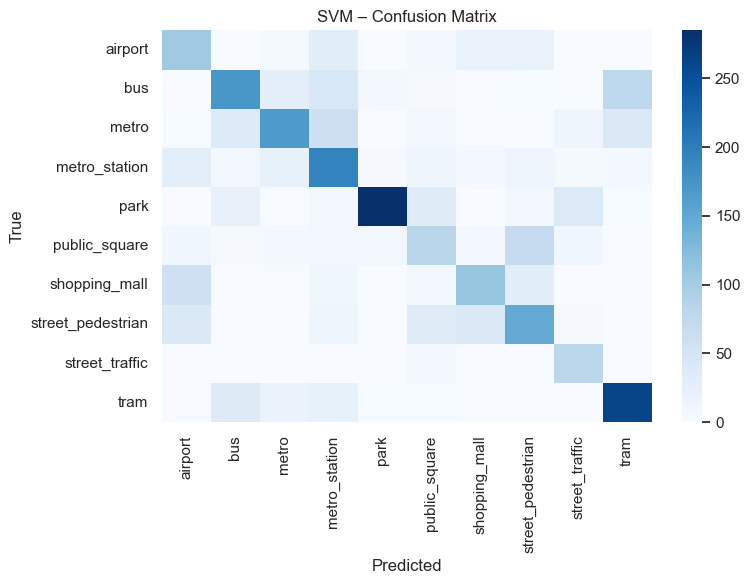

In [6]:
# confusion matrix
cm = confusion_matrix(y_te, y_pred_te)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=False, cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('SVM – Confusion Matrix')
plt.tight_layout()
plt.show()


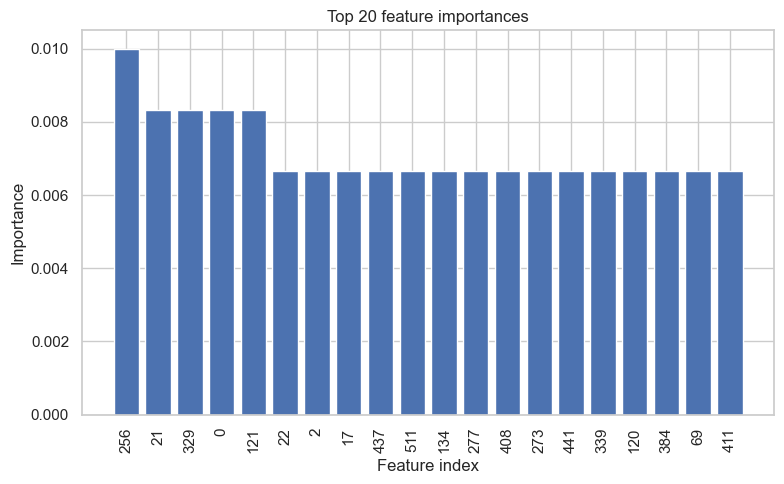

In [12]:
# feature importance
import joblib
from sklearn.inspection import permutation_importance
from sklearn.utils import resample

if os.path.exists('svm_model.joblib'):
    clf_svm = joblib.load('svm_model.joblib')
n_samples = min(300, X_va.shape[0])

X_imp, y_imp = resample(
    X_va, y_va,
    n_samples=n_samples,
    replace=False,
    random_state=RANDOM_STATE,
)

r = permutation_importance(
    clf_svm,
    X_imp,
    y_imp,
    n_repeats=2,
    random_state=RANDOM_STATE,
    n_jobs=1,
)

importances = r.importances_mean
indices = np.argsort(importances)[::-1][:20]

plt.figure(figsize=(8, 5))
plt.bar(range(len(indices)), importances[indices])
plt.xticks(range(len(indices)), indices, rotation=90)
plt.title("Top 20 feature importances")
plt.xlabel("Feature index")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()
